# Coherent-Basis Optimization — New API Demo

**C. Blake, G. Zheng, G. Lee, and L. Jiang — March 2026**

In [1]:
import sys
sys.path.insert(0, 'coherax')
import numpy as np
import scipy.special as sp
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import dynamiqs as dq

from coherax import (
    CoherentKet, FockKet, QubitKet, JointKet,
    CoherentDM, FockDM, Displacer, Rotator, CPTP, GKP_N,
    state_fidelity, circuit_state_fidelity, circuit_fock_fidelity,
    analytic_fidelity_wrapper, analytic_fidelity_transfer_wrapper,
    analytic_fidelity_fock_wrapper, CircuitUnitary,
    g, compose_ECD_layers, traceout_unitary, circuit_params_to_time,
    apply_kraus_map, make_pureloss_fock, dqfock_dm, dqtrace, dqptrace,
    dqdag, dqtensor, dqdisplace, dqsqueeze, coherent_overlap, gkp_coherent_dm,
    optimize_ECD_state_prep, optimize_ECD_state_transfer,
)


def ic_fock(psi0, psi1, gamma, loss_rank=15):
    """Coherent information I_c (qubits) for two Fock-basis logical kets
    under the pure-loss channel. Local helper used by the I_c sweep below."""
    N_fock = psi0.shape[0]
    ops = make_pureloss_fock(gamma, loss_rank, N_fock)
    v0 = jnp.einsum('knm,m->kn', ops, psi0)
    v1 = jnp.einsum('knm,m->kn', ops, psi1)
    b00 = jnp.einsum('kn,km->nm', v0, jnp.conj(v0))
    b11 = jnp.einsum('kn,km->nm', v1, jnp.conj(v1))
    b01 = jnp.einsum('kn,km->nm', v0, jnp.conj(v1))
    b10 = jnp.einsum('kn,km->nm', v1, jnp.conj(v0))
    rho_B = 0.5 * (b00 + b11)
    rho_RB = 0.5 * jnp.block([[b00, b01], [b10, b11]])
    def _ent(rho):
        w = jnp.real(jnp.linalg.eigvalsh(rho))
        return float(-jnp.sum(jnp.where(w > 1e-15, w * jnp.log2(jnp.maximum(w, 1e-30)), 0.0)))
    return _ent(rho_B) - _ent(rho_RB)


def ic_coherent(ket0, ket1, gamma, loss_rank=15):
    """I_c for two CoherentKet logical codewords; projects to Fock first."""
    return ic_fock(ket0.to_fock_ket(), ket1.to_fock_ket(), gamma, loss_rank)


plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 9, 'figure.dpi': 150})
DATA = 'testing_data'
print(f'JAX devices: {jax.devices()}')
print(f'Fock truncation: N = {GKP_N}')

JAX devices: [CpuDevice(id=0)]
Fock truncation: N = 100


---
## 1. New API Quick Demo

In [2]:
cat = CoherentKet(cs=jnp.array([1.0, 1.0]), ds=jnp.array([2.0+0j, -2.0+0j]))
fock3 = FockKet(cs=jnp.array([1.0]), ns=jnp.array([3]))
print(f'|<cat|3>|^2 = {state_fidelity(cat, fock3):.6f}')

D = Displacer(beta=1.0+0j)
R = Rotator(theta=jnp.pi/2)
print(f'D(1)|cat> ds: {D.apply(cat).ds}')
print(f'R(pi/2)|cat> ds: {jnp.round(R.apply(cat).ds, 4)}')

dm = CoherentDM.from_ket(cat)
print(f'D(1) rho D+(1) ds: {D.apply_dm(dm).ds}')

|<cat|3>|^2 = 0.000000
D(1)|cat> ds: [ 3.+0.j -1.+0.j]
R(pi/2)|cat> ds: [ 0.+2.j -0.-2.j]
D(1) rho D+(1) ds: [ 3.+0.j -1.+0.j]


---
## 2. GKP State Preparation (New API)

In [3]:
Delta_034 = 0.34
x3_prep = np.load(f'{DATA}/exp_C1_x3_100restart.npz', allow_pickle=True)
x4_prep = np.load(f'{DATA}/exp_C2_x4_100restart.npz', allow_pickle=True)
x3_to_x3y3 = np.load(f'{DATA}/GKP_D034_x3_to_x3y3_prep.npz')
x3_prep_params = jnp.array(x3_prep['params'])
x4_prep_params = jnp.array(x4_prep['params'])
x3_to_x3y3_params = jnp.array(x3_to_x3y3['params'])

gkp_x3 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice='square', N_trunc_y=0)
gkp_x4 = gkp_coherent_dm(mu=0, N_trunc=4, Delta=Delta_034, lattice='square', N_trunc_y=0)
gkp_3 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice='square')

# ===== NEW API =====
x3_N_l = 2 ** x3_prep_params.shape[0]
x4_N_l = 2 ** x4_prep_params.shape[0]
x3_fid = float(circuit_state_fidelity(gkp_x3, x3_prep_params, x3_N_l))
x4_fid = float(circuit_state_fidelity(gkp_x4, x4_prep_params, x4_N_l))

# Cross-check old API
x3_fid_old = float(analytic_fidelity_wrapper(gkp_x3, x3_prep_params, x3_N_l))
print(f'X3 fidelity:  new={x3_fid:.8f}  old={x3_fid_old:.8f}')
print(f'X4 fidelity:  new={x4_fid:.8f}')

X3 fidelity:  new=0.99998753  old=0.99998779
X4 fidelity:  new=0.99998749


CircuitUnitary: JointKet, cs shape=(2, 2048)


state_fidelity = 0.99998753


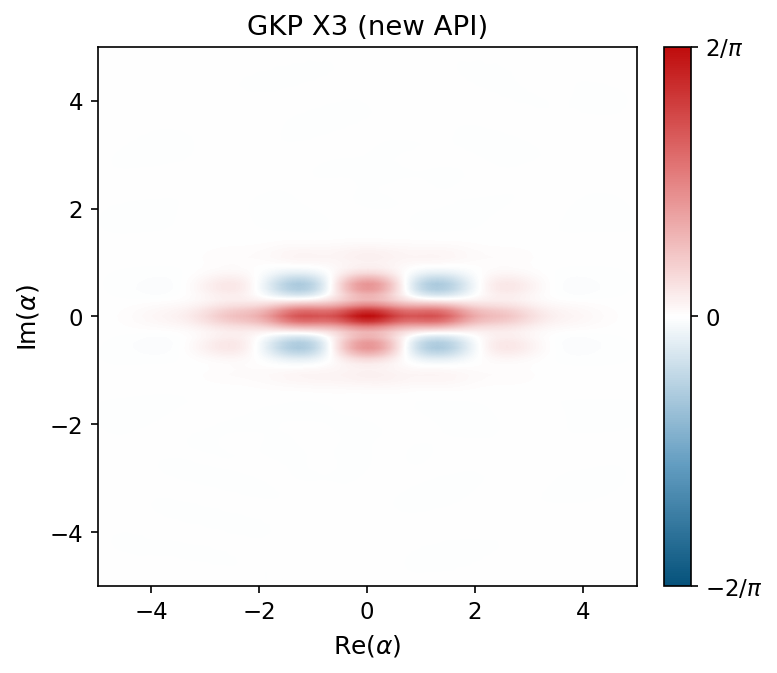

In [4]:
# CircuitUnitary.apply -> JointKet -> project
U = CircuitUnitary.from_params(x3_prep_params, x3_N_l)
vac = CoherentKet(cs=jnp.array([1.0]), ds=jnp.array([0.0+0j]))
q0 = QubitKet(cs=jnp.array([1.0, 0.0]))
output = U.apply(vac, q0)
bosonic = output.inner(q0)
print(f'CircuitUnitary: {type(output).__name__}, cs shape={output.cs.shape}')
print(f'state_fidelity = {float(state_fidelity(gkp_x3, bosonic)):.8f}')
dq.plot.wigner(bosonic.to_fock_basis())
plt.title('GKP X3 (new API)')
plt.show()

/opt/miniconda3/envs/coherax/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


X3Y3 pipeline: F=0.999804, 1-F=1.96e-04


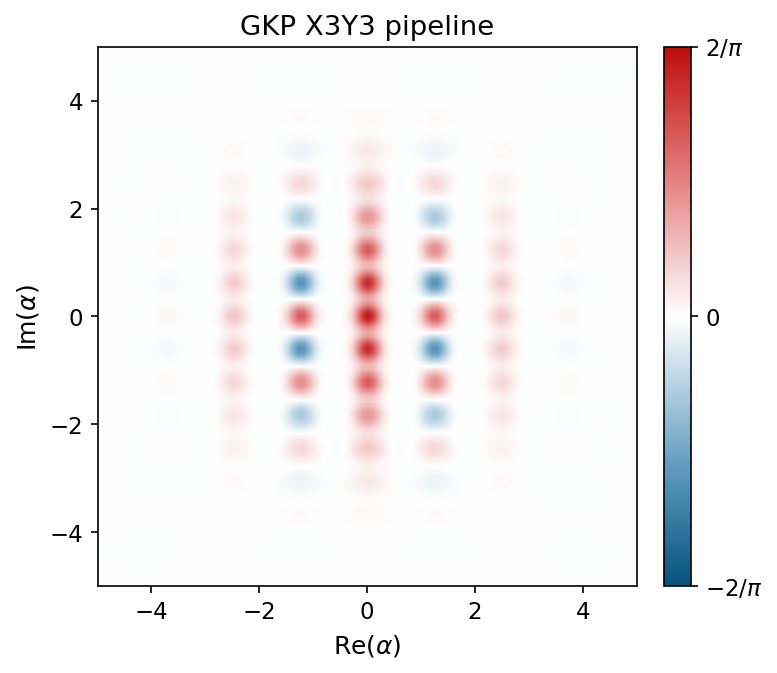

In [5]:
# Pipeline fidelity (Fock-basis for mixed-state intermediate)
rho_gkp3_fock = gkp_3.to_fock_basis()
rho_prep = apply_kraus_map(traceout_unitary(compose_ECD_layers(x3_prep_params)), dqfock_dm(GKP_N, 0))
rho_final = apply_kraus_map(traceout_unitary(compose_ECD_layers(x3_to_x3y3_params)), rho_prep)
PIPELINE_F = float(jnp.real(dqtrace(rho_final @ rho_gkp3_fock)))
print(f'X3Y3 pipeline: F={PIPELINE_F:.6f}, 1-F={1-PIPELINE_F:.2e}')
dq.plot.wigner(rho_final)
plt.title('GKP X3Y3 pipeline')
plt.show()

---
## 3. Fock State Preparation (New API)

Using `circuit_fock_fidelity(m, params, N_l)`.

In [6]:
fock = np.load(f'{DATA}/fock_preparation.npz')
fock_depths = [4, 6, 8, 10]
fock_states = list(range(1, 9))
print('Fock State Prep (NEW API)')
print('=' * 60)
results = {}
for tn in fock_states:
    results[tn] = {}
    for d in fock_depths:
        params = jnp.array(fock[f'n{tn}_d{d}_params'])
        N_l = 2 ** d
        fid = float(circuit_fock_fidelity(tn, params, N_l))
        t = circuit_params_to_time(params) * 1e6
        results[tn][d] = {'fidelity': fid, 'time_us': t}
        print(f'  |{tn}> d={d}: F={fid:.8f}  1-F={1-fid:.2e}  T={t:.2f}us')
    print()

Fock State Prep (NEW API)


  |1> d=4: F=0.99843196  1-F=1.57e-03  T=0.62us


  |1> d=6: F=0.99999720  1-F=2.80e-06  T=0.66us


  |1> d=8: F=0.99999985  1-F=1.45e-07  T=0.76us


  |1> d=10: F=0.99999979  1-F=2.06e-07  T=0.85us

  |2> d=4: F=0.97401120  1-F=2.60e-02  T=0.89us
  |2> d=6: F=0.99994673  1-F=5.33e-05  T=1.16us
  |2> d=8: F=0.99999860  1-F=1.40e-06  T=1.01us


...

  |4> d=10: F=0.99999767  1-F=2.33e-06  T=1.40us

  |5> d=4: F=0.78657717  1-F=2.13e-01  T=1.22us
  |5> d=6: F=0.98023635  1-F=1.98e-02  T=1.59us
  |5> d=8: F=0.99958505  1-F=4.15e-04  T=1.37us


  |5> d=10: F=0.99999334  1-F=6.66e-06  T=1.58us

  |6> d=4: F=0.00000000  1-F=1.00e+00  T=0.29us
  |6> d=6: F=0.96474309  1-F=3.53e-02  T=1.74us
  |6> d=8: F=0.99533848  1-F=4.66e-03  T=1.60us


  |6> d=10: F=0.99997944  1-F=2.06e-05  T=1.63us

  |7> d=4: F=0.00000000  1-F=1.00e+00  T=0.29us
  |7> d=6: F=0.93652171  1-F=6.35e-02  T=1.85us
  |7> d=8: F=0.97975851  1-F=2.02e-02  T=2.12us


  |7> d=10: F=0.99968637  1-F=3.14e-04  T=2.06us

  |8> d=4: F=0.00000000  1-F=1.00e+00  T=0.29us
  |8> d=6: F=0.90031524  1-F=9.97e-02  T=1.68us
  |8> d=8: F=0.96356132  1-F=3.64e-02  T=1.93us


  |8> d=10: F=0.99295270  1-F=7.05e-03  T=2.09us



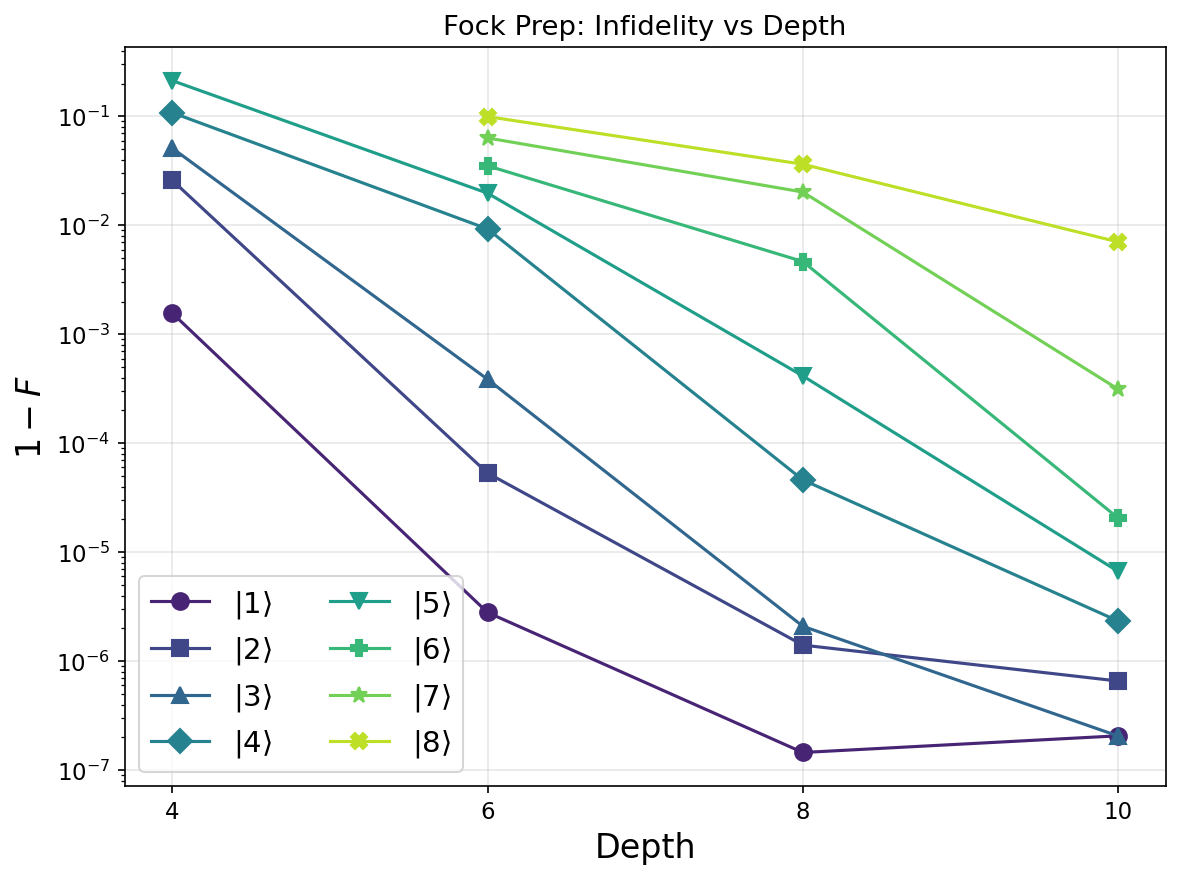

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 8))
for i, tn in enumerate(fock_states):
    infids = [1-results[tn][d]['fidelity'] for d in fock_depths if results[tn][d]['fidelity']>0.01]
    vd = [d for d in fock_depths if results[tn][d]['fidelity']>0.01]
    if vd:
        ax.semilogy(vd, infids, f'{markers[i]}-', label=f'$|{tn}\\rangle$', markersize=8, color=colors[i])
ax.set_xlabel('Depth', fontsize=16); ax.set_ylabel('$1-F$', fontsize=16)
ax.set_title('Fock Prep: Infidelity vs Depth')
ax.legend(fontsize=14, ncol=2); ax.grid(True, alpha=0.3); ax.set_xticks(fock_depths)
plt.tight_layout(); plt.show()

---
## 4. I_c Comparison (unchanged — already uses CoherentKet)

In [8]:
def gkp_square(D, N=5):
    return (gkp_coherent_dm(mu=0,N_trunc=N,Delta=D,lattice='square'),
            gkp_coherent_dm(mu=1,N_trunc=N,Delta=D,lattice='square'))
def gkp_hex(D, N=5):
    a = jnp.sqrt(jnp.pi/jnp.sqrt(3.0)); b = a*jnp.exp(1j*jnp.pi/3)
    sts = []
    for mu in range(2):
        cs,ds = [],[]
        for k in range(-N,N+1):
            for l in range(-N,N+1):
                d = (2*k+mu)*a+l*b
                cs.append(jnp.exp(-1j*jnp.pi*(k*l+l*mu/2)-D**2*jnp.abs(d)**2)); ds.append(d)
        sts.append(CoherentKet(cs=jnp.array(cs),ds=jnp.array(ds)))
    return sts[0],sts[1]
def nbar_ck(s):
    A=s.ds.shape[0]; da,db=s.ds.reshape(A,1),s.ds.reshape(1,A)
    G=coherent_overlap(da,db)
    return float(jnp.real(jnp.sum(jnp.conj(s.cs.reshape(A,1))*s.cs.reshape(1,A)*jnp.conj(da)*db*G)))
def nbar_code(l0,l1): return .5*(nbar_ck(l0)+nbar_ck(l1))
def find_delta(t, N=5, lat='hex'):
    fn=gkp_hex if lat=='hex' else gkp_square; lo,hi=.1,1.
    for _ in range(50):
        m=(lo+hi)/2; nb=float(nbar_code(*fn(m,N)))
        if nb>t: lo=m
        else: hi=m
    return (lo+hi)/2
def sg(mu,D,Nf=GKP_N,nt=15):
    r=-np.log(D); a=np.sqrt(np.pi/2)
    sv=dqsqueeze(Nf,r)@jnp.zeros(Nf,dtype=jnp.complex128).at[0].set(1.)
    p=sum(np.exp(-np.pi*D**2*(2*n+mu)**2/4)*(dqdisplace(Nf,(2*n+mu)*a)@sv) for n in range(-nt,nt+1))
    return p/jnp.linalg.norm(p)
def sb(mu,D,Nf=GKP_N):
    r=-np.log(D); a=np.sqrt(np.pi/2); Nb=int(.32/D**2)
    sv=dqsqueeze(Nf,r)@jnp.zeros(Nf,dtype=jnp.complex128).at[0].set(1.)
    p=sum(np.sqrt(float(sp.comb(Nb,n+mu+Nb//2,exact=True)))*(dqdisplace(Nf,(2*n+mu)*a)@sv) for n in range(-(Nb+mu)//2,(Nb+mu)//2-mu+1))
    return p/jnp.linalg.norm(p)

Computing I_c...


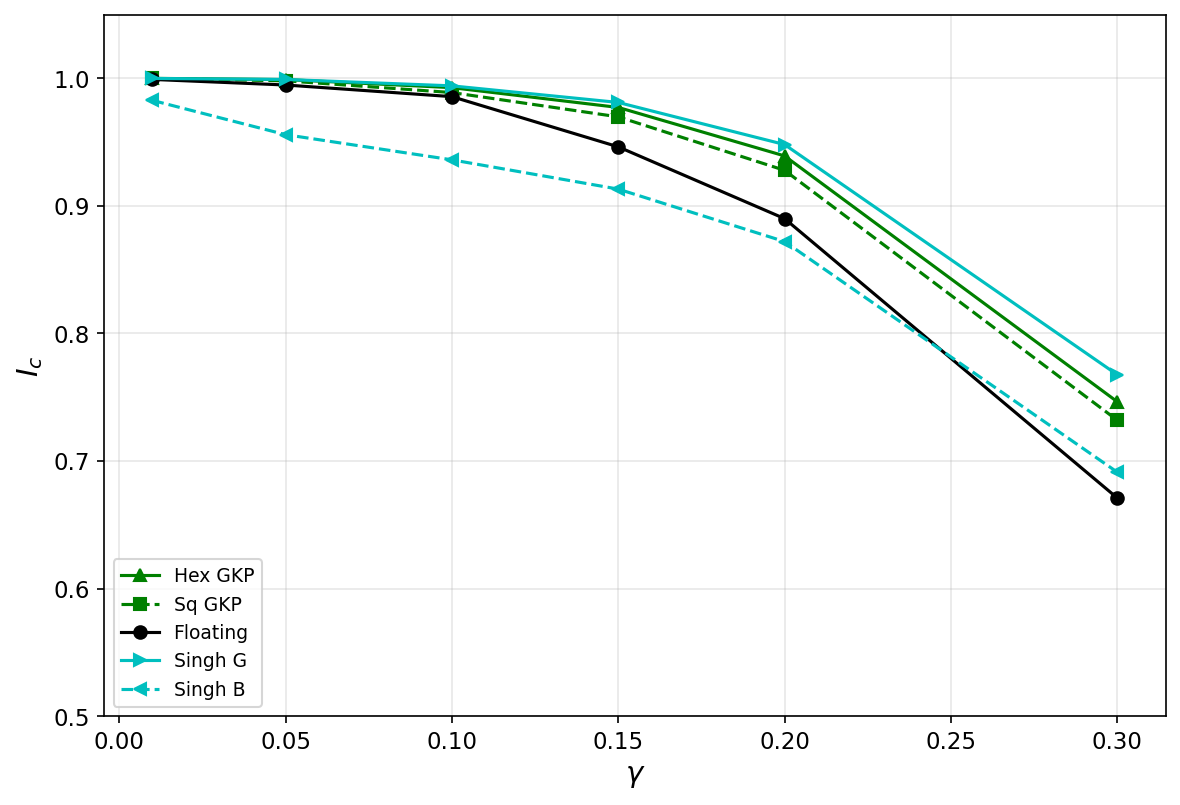

In [9]:
ic_st = np.load(f'{DATA}/Ic_comparison_results.npz', allow_pickle=True)
fb = np.load(f'{DATA}/results_vacuum.npz', allow_pickle=True)
gs = np.array([.01,.05,.1,.15,.2,.3]); gss=['0.01','0.05','0.10','0.15','0.20','0.30']
nbs = ic_st['nbar_targets']
nms = ['Hex GKP','Sq GKP','Floating','Singh G','Singh B']; Ic = np.zeros((5,6))
print('Computing I_c...')
for j,gam in enumerate(gs):
    gam,nb=float(gam),float(nbs[j])
    dh=find_delta(nb,lat='hex'); ds_=find_delta(nb,lat='square')
    Ic[0,j]=ic_coherent(*gkp_hex(dh),gam,loss_rank=15)
    Ic[1,j]=ic_coherent(*gkp_square(ds_),gam,loss_rank=15)
    s=gss[j]
    Ic[2,j]=ic_coherent(
        CoherentKet(jnp.array(fb[f'nc10_g{s}_cs0']),jnp.array(fb[f'nc10_g{s}_ds0'])),
        CoherentKet(jnp.array(fb[f'nc10_g{s}_cs1']),jnp.array(fb[f'nc10_g{s}_ds1'])),gam,loss_rank=15)
    Ic[3,j]=ic_fock(sg(0,dh),sg(1,dh),gam,loss_rank=15)
    Ic[4,j]=ic_fock(sb(0,dh),sb(1,dh),gam,loss_rank=15)
fig,ax=plt.subplots(figsize=(8,5.5))
for i,(n,s) in enumerate(zip(nms,['g^-','gs--','ko-','c>-','c<--'])):
    ax.plot(gs,Ic[i],s,label=n,markersize=6)
ax.set_xlabel(r'$\gamma$',fontsize=14); ax.set_ylabel(r'$I_c$',fontsize=14)
ax.legend(loc='lower left',fontsize=9); ax.grid(True,alpha=.3); ax.set_ylim([.5,1.05])
plt.tight_layout(); plt.show()

---
## 5. ECD Optimization (new API verification)

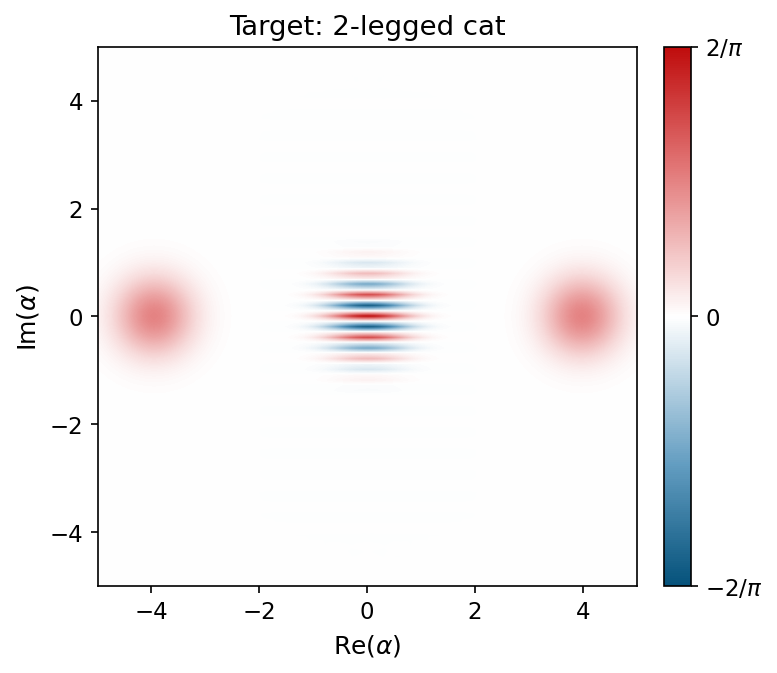

In [10]:
target_cat = CoherentKet(cs=jnp.array([1,1]), ds=jnp.array([4.0+0j, -4.0+0j]))
dq.plot.wigner(target_cat.to_fock_basis())
plt.title('Target: 2-legged cat'); plt.show()

In [11]:
N_depth = 6
best_params, best_loss = optimize_ECD_state_prep(
    target_state=target_cat, restarts=2, steps=15000, lr=.001,
    N_depth=N_depth, random_dist=.1, random_angle=1,
    initial=jnp.zeros((6,4), dtype=jnp.complex64))
print(f'Infidelity: {best_loss:.2e}')

/opt/miniconda3/envs/coherax/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/coherax/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Restart 0, Step 0, 1 - F = 1.000000
Restart 0, Step 100, 1 - F = 0.999999
Restart 0, Step 200, 1 - F = 0.999959
Restart 0, Step 300, 1 - F = 0.994687
Restart 0, Step 400, 1 - F = 0.851297
Restart 0, Step 500, 1 - F = 0.502038
Restart 0, Step 600, 1 - F = 0.328171
Restart 0, Step 700, 1 - F = 0.168414


Restart 0, Step 800, 1 - F = 0.082802
Restart 0, Step 900, 1 - F = 0.050866
Restart 0, Step 1000, 1 - F = 0.035039
Restart 0, Step 1100, 1 - F = 0.025308
Restart 0, Step 1200, 1 - F = 0.018822
Restart 0, Step 1300, 1 - F = 0.014400
Restart 0, Step 1400, 1 - F = 0.011393
Restart 0, Step 1500, 1 - F = 0.009371
Restart 0, Step 1600, 1 - F = 0.008025


Restart 0, Step 1700, 1 - F = 0.007132
Restart 0, Step 1800, 1 - F = 0.006532
Restart 0, Step 1900, 1 - F = 0.006120
Restart 0, Step 2000, 1 - F = 0.005827
Restart 0, Step 2100, 1 - F = 0.005611
Restart 0, Step 2200, 1 - F = 0.005444
Restart 0, Step 2300, 1 - F = 0.005309
Restart 0, Step 2400, 1 - F = 0.005193
Restart 0, Step 2500, 1 - F = 0.005090


Restart 0, Step 2600, 1 - F = 0.004992
Restart 0, Step 2700, 1 - F = 0.004897
Restart 0, Step 2800, 1 - F = 0.004800
Restart 0, Step 2900, 1 - F = 0.004701
Restart 0, Step 3000, 1 - F = 0.004600
Restart 0, Step 3100, 1 - F = 0.004493
Restart 0, Step 3200, 1 - F = 0.004382
Restart 0, Step 3300, 1 - F = 0.004266
Restart 0, Step 3400, 1 - F = 0.004144


...

Restart 1, Step 11300, 1 - F = 0.000148
Restart 1, Step 11400, 1 - F = 0.000147
Restart 1, Step 11500, 1 - F = 0.000146
Restart 1, Step 11600, 1 - F = 0.000146
Restart 1, Step 11700, 1 - F = 0.000145
Restart 1, Step 11800, 1 - F = 0.000145
Restart 1, Step 11900, 1 - F = 0.000144
Restart 1, Step 12000, 1 - F = 0.000144
Restart 1, Step 12100, 1 - F = 0.000143


Restart 1, Step 12200, 1 - F = 0.000141
Restart 1, Step 12300, 1 - F = 0.000141
Restart 1, Step 12400, 1 - F = 0.000140
Restart 1, Step 12500, 1 - F = 0.000139
Restart 1, Step 12600, 1 - F = 0.000138
Restart 1, Step 12700, 1 - F = 0.000136
Restart 1, Step 12800, 1 - F = 0.000135
Restart 1, Step 12900, 1 - F = 0.000134
Restart 1, Step 13000, 1 - F = 0.000131


Restart 1, Step 13100, 1 - F = 0.000130
Restart 1, Step 13200, 1 - F = 0.000127
Restart 1, Step 13300, 1 - F = 0.000125
Restart 1, Step 13400, 1 - F = 0.000122
Restart 1, Step 13500, 1 - F = 0.000119
Restart 1, Step 13600, 1 - F = 0.000116
Restart 1, Step 13700, 1 - F = 0.000112
Restart 1, Step 13800, 1 - F = 0.000108
Restart 1, Step 13900, 1 - F = 0.000103


Restart 1, Step 14000, 1 - F = 0.000097
Restart 1, Step 14100, 1 - F = 0.000091
Restart 1, Step 14200, 1 - F = 0.000083
Restart 1, Step 14300, 1 - F = 0.000076
Restart 1, Step 14400, 1 - F = 0.000068
Restart 1, Step 14500, 1 - F = 0.000061
Restart 1, Step 14600, 1 - F = 0.000052
Restart 1, Step 14700, 1 - F = 0.000045


Restart 1, Step 14800, 1 - F = 0.000038
Restart 1, Step 14900, 1 - F = 0.000031
1 new best 2.6335534985544307e-05
[[-4.5438960e-01-0.2877378j   1.5707890e+00+0.j
   1.5707958e+00+0.j          0.0000000e+00+0.j        ]
 [-2.8109677e+00+0.01847362j -3.9268553e-02+0.j
   3.0049419e+00+0.j          0.0000000e+00+0.j        ]
 [-2.6739745e+00+0.0711444j   3.9293393e-02+0.j
   3.1419144e+00+0.j          0.0000000e+00+0.j        ]
 [ 2.0925984e+00-0.2829669j   1.6525770e-05+0.j
  -2.4473185e-03+0.j          0.0000000e+00+0.j        ]
 [-3.5597179e-02-0.19478583j  3.1415906e+00+0.j
  -1.3953770e+00+0.j          0.0000000e+00+0.j        ]
 [ 1.9600923e-01-0.02238428j  2.6753659e+00+0.j
   1.6381764e+00+0.j          0.0000000e+00+0.j        ]]
Infidelity: 2.63e-05


Fidelity (new): 0.99997409
Fidelity (old): 0.99997409


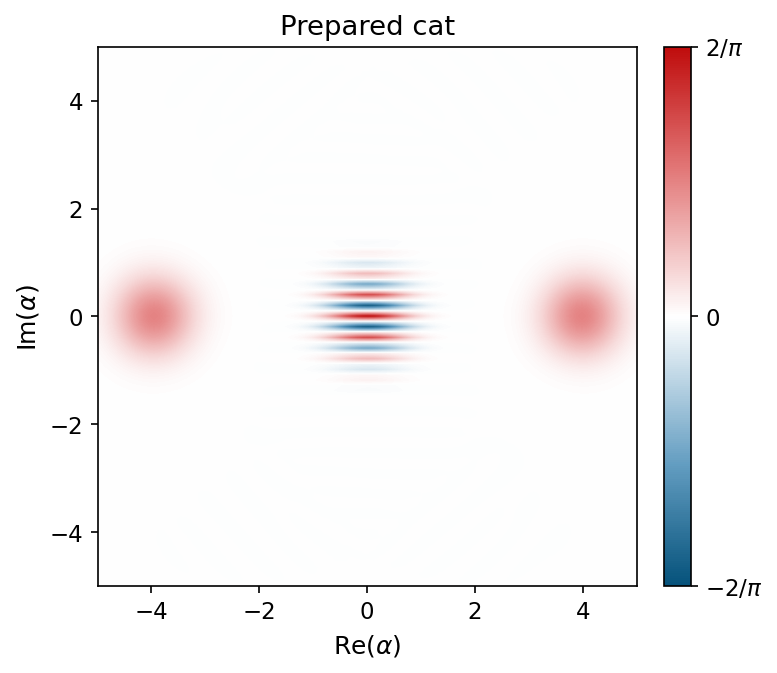

In [12]:
# Verify with NEW API
N_l = 2**N_depth
U = CircuitUnitary.from_params(best_params, N_l)
vac = CoherentKet(cs=jnp.array([1.0]), ds=jnp.array([0.0+0j]))
q0 = QubitKet(cs=jnp.array([1.0, 0.0]))
bosonic_out = U.apply(vac, q0).inner(q0)
fid_new = float(state_fidelity(target_cat, bosonic_out))

# Cross-check old Fock method
prepped = apply_kraus_map(traceout_unitary(compose_ECD_layers(best_params)), dqfock_dm(GKP_N,0))
fid_old = float(jnp.real(jnp.trace(prepped @ target_cat.to_fock_basis())))

print(f'Fidelity (new): {fid_new:.8f}')
print(f'Fidelity (old): {fid_old:.8f}')
dq.plot.wigner(prepped)
plt.title('Prepared cat'); plt.show()

In [13]:
# State transfer: 2-leg -> 4-leg cat
start = CoherentKet(cs=jnp.array([1,1]), ds=jnp.array([2.0+0j,-2.0+0j]))
final = CoherentKet(cs=jnp.array([1,1,1,1]), ds=jnp.array([2+2j,-2+2j,2-2j,-2-2j]))
tp, tl = optimize_ECD_state_transfer(
    start_state=start, final_state=final, T_depth=1, N_depth=7,
    lr=.01, steps=20000, restarts=20, random_dist=1., random_angle=jnp.pi)
print(f'Transfer infidelity: {tl:.2e}')

/opt/miniconda3/envs/coherax/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/coherax/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


[[[-0.22264521-0.4236879j   5.661496  +0.j
    0.5667152 +0.j          5.4400644 +0.j        ]
  [-0.72390497+1.7072588j   4.1052756 +0.j
    2.707121  +0.j          1.0791783 +0.j        ]
  [-0.9715273 +1.7333957j   1.1847203 +0.j
    2.790676  +0.j          3.8932114 +0.j        ]
  [-0.59474254+0.634688j    4.4444427 +0.j
    2.3651254 +0.j          0.6569152 +0.j        ]
  [-1.4530654 +1.9356884j   1.6620796 +0.j
    3.9133418 +0.j          0.42756328+0.j        ]
  [-0.15284914-0.02310796j  2.0265996 +0.j
    2.071452  +0.j          5.1856    +0.j        ]
  [ 1.1958121 +0.39044347j  3.315266  +0.j
    3.200273  +0.j          1.8369311 +0.j        ]]]


Restart 0, Step 0, 1 - F = 0.988599
Restart 0, Step 100, 1 - F = 0.532827


Restart 0, Step 200, 1 - F = 0.427735
Restart 0, Step 300, 1 - F = 0.418553


Restart 0, Step 400, 1 - F = 0.406844
Restart 0, Step 500, 1 - F = 0.390126


...

Restart 19, Step 19200, 1 - F = 0.007004
Restart 19, Step 19300, 1 - F = 0.007004


Restart 19, Step 19400, 1 - F = 0.007004
Restart 19, Step 19500, 1 - F = 0.007004


Restart 19, Step 19600, 1 - F = 0.007004
Restart 19, Step 19700, 1 - F = 0.007004


Restart 19, Step 19800, 1 - F = 0.007006
Restart 19, Step 19900, 1 - F = 0.007004


Transfer infidelity: 2.30e-03


Fidelity: 0.99769922


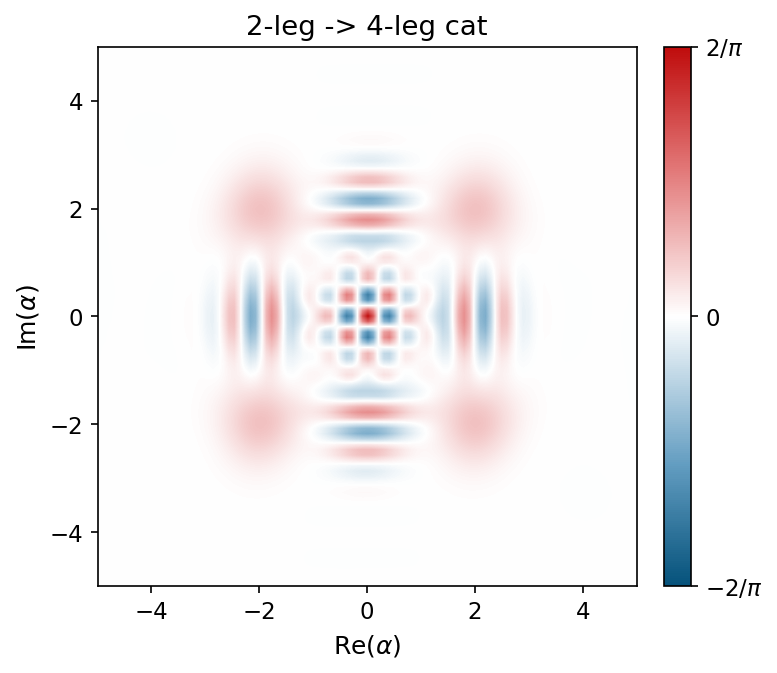

In [14]:
transferred = apply_kraus_map(traceout_unitary(compose_ECD_layers(tp[0])), start.to_fock_basis())
print(f'Fidelity: {float(jnp.real(jnp.trace(transferred @ final.to_fock_basis()))):.8f}')
dq.plot.wigner(transferred)
plt.title('2-leg -> 4-leg cat'); plt.show()